In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
# Folder path
folder_path = 'path_to_your_folder'

# Reading the data
vt_data = pd.read_csv("VT_categorized_data.csv")
gld_data = pd.read_csv("GLD_categorized_data.csv")
qqq_data = pd.read_csv("QQQ_categorized_data.csv")

# Adding a column for Dataset
vt_data['Dataset'] = 'VT'
gld_data['Dataset'] = 'GLD'
qqq_data['Dataset'] = 'QQQ'

# Merging the data
combined_data = pd.concat([vt_data, gld_data, qqq_data], ignore_index=True)

# Checking the data
print(combined_data.head())


         Date    Open    High     Low   Close  Volume     Open_category  \
0  2008-07-01  42.449  42.857  41.247  42.423   63725   (41.86, 42.647]   
1  2008-07-02  42.802  42.931  41.799  41.799   86429  (42.647, 43.434]   
2  2008-07-07  42.145  42.163  41.300  41.827   64235   (41.86, 42.647]   
3  2008-07-08  41.574  41.957  40.758  41.907   62746   (41.073, 41.86]   
4  2008-07-23  42.674  42.742  42.285  42.406   54540  (42.647, 43.434]   

      High_category      Low_category    Close_category  \
0  (42.825, 43.611]  (40.814, 41.604]  (41.785, 42.578]   
1  (42.825, 43.611]  (41.604, 42.395]  (41.785, 42.578]   
2  (42.038, 42.825]  (40.814, 41.604]  (41.785, 42.578]   
3  (41.251, 42.038]  (40.023, 40.814]  (41.785, 42.578]   
4  (42.038, 42.825]  (41.604, 42.395]  (41.785, 42.578]   

                   Volume_category Dataset  
0  (52136.886000000006, 68907.043]      VT  
1          (84580.086, 100253.129]      VT  
2  (52136.886000000006, 68907.043]      VT  
3  (52136.8860

In [5]:
# Save the combined data to a CSV file
output_path = "Combined_Dataset.csv"
combined_data.to_csv(output_path, index=False)

print(f"Combined data saved to {output_path}")


Combined data saved to Combined_Dataset.csv


#### Volatility Comparison

Volatility by Close_category

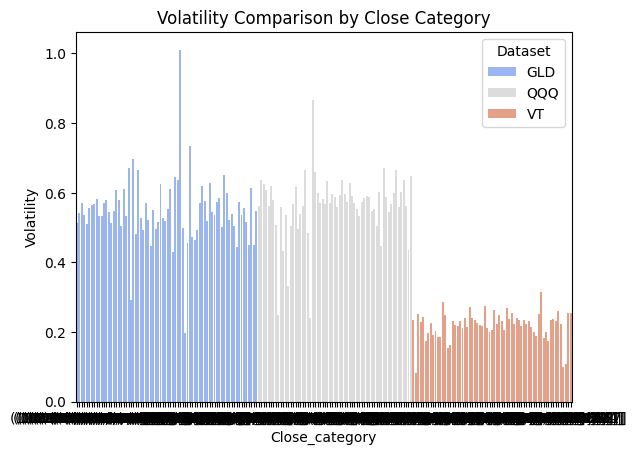

In [8]:
# Group by Close_category
category_volatility = combined_data.groupby(['Dataset', 'Close_category'])['Close'].std().reset_index()

# Rename the column
category_volatility.rename(columns={'Close': 'Volatility'}, inplace=True)

# Plot as before
sns.barplot(data=category_volatility, x='Close_category', y='Volatility', hue='Dataset', palette='coolwarm')
plt.title("Volatility Comparison by Close Category")
plt.show()


Volatility using a 30-Day Rolling Window

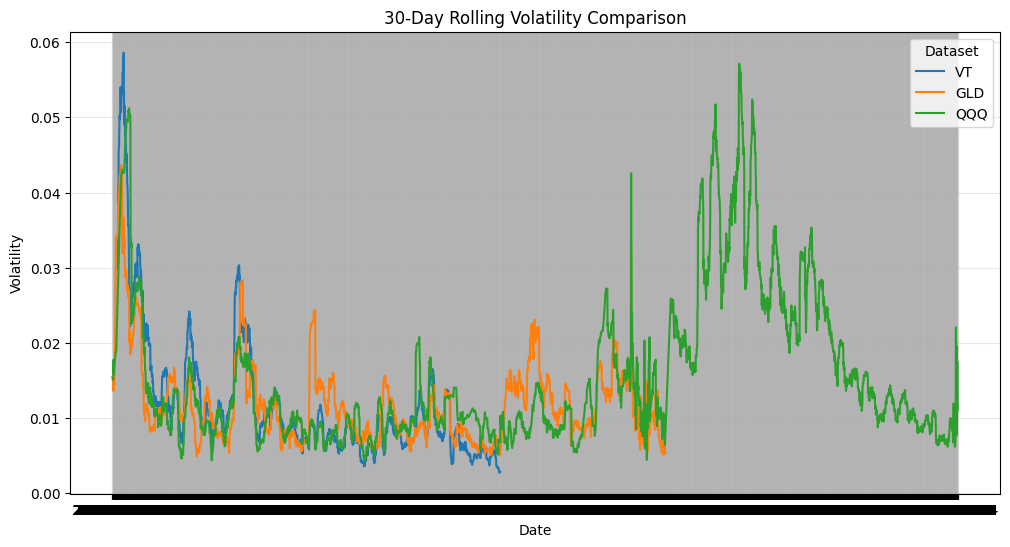

In [7]:

# Calculate daily returns for each Dataset
combined_data['Daily_Return'] = combined_data.groupby('Dataset')['Close'].pct_change()

# Calculate 30-day rolling volatility
combined_data['Volatility'] = combined_data.groupby('Dataset')['Daily_Return'].rolling(window=30).std().reset_index(level=0, drop=True)

# Plot volatility comparison
plt.figure(figsize=(12, 6))
sns.lineplot(data=combined_data, x='Date', y='Volatility', hue='Dataset')
plt.title("30-Day Rolling Volatility Comparison")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend(title="Dataset")
plt.grid(alpha=0.3)
plt.show()


#### Total Returns Comparison

This code calculates the Total Returns for each Dataset (i.e. VT, GLD, QQQ). The Total Return represents the percentage change in the Closing Price from the first record to the last record in the data.

In [9]:
# Calculate total returns for each Dataset
total_returns = combined_data.groupby('Dataset').apply(
    lambda x: (x['Close'].iloc[-1] - x['Close'].iloc[0]) / x['Close'].iloc[0]
)
print("Total Returns:")
print(total_returns)


Total Returns:
Dataset
GLD    1.802638
QQQ    2.349608
VT     0.703086
dtype: float64


C:\Users\niush\AppData\Local\Temp\ipykernel_22376\299058788.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  total_returns = combined_data.groupby('Dataset').apply(


#### Correlation Between Datasets

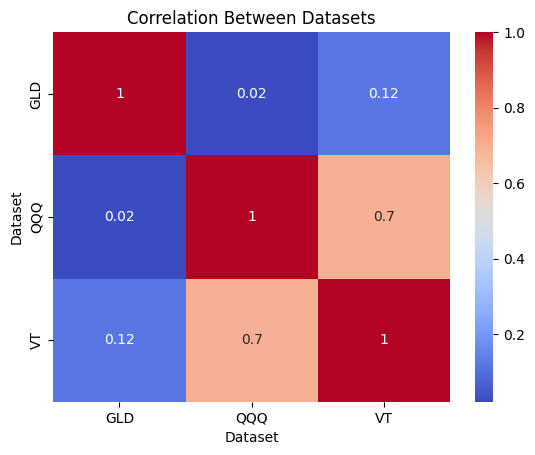

In [10]:
# Create a DataFrame of daily returns
returns_data = combined_data.pivot(index='Date', columns='Dataset', values='Daily_Return')

# Calculate the correlation matrix
correlation_matrix = returns_data.corr()

# Plot the correlation matrix as a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Between Datasets")
plt.show()


#### Time Series Trends Comparison

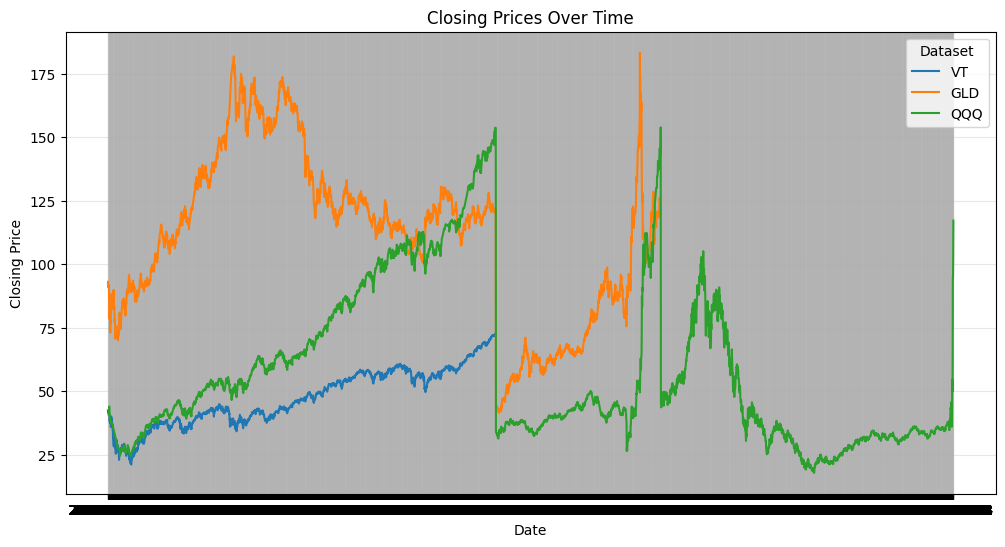

In [11]:
# Plot closing prices over time for each dataset
plt.figure(figsize=(12, 6))
sns.lineplot(data=combined_data, x='Date', y='Close', hue='Dataset')
plt.title("Closing Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend(title="Dataset")
plt.grid(alpha=0.3)
plt.show()


#### Descriptive Statistics Comparison

In [14]:
pd.set_option('display.max_columns', None)

In [15]:
# Calculate descriptive statistics for numerical columns
descriptive_stats = combined_data.groupby('Dataset')[['Open', 'Close', 'High', 'Low', 'Volume']].describe()
descriptive_stats

Open                                                              \
          count        mean        std    min       25%      50%        75%   
Dataset                                                                       
GLD      2881.0  110.671552  32.058051  41.45  87.85000  116.210  127.62000   
QQQ      4231.0   57.027859  29.853908  17.83  34.71050   45.524   73.75400   
VT       2124.0   47.550385  11.230562  21.40  38.70875   46.549   56.90025   

                  Close                                                   \
            max   count        mean        std     min      25%      50%   
Dataset                                                                    
GLD      182.82  2881.0  110.691718  32.077568  41.620  87.8900  116.090   
QQQ      153.67  4231.0   57.014087  29.853178  17.938  34.6465   45.439   
VT        72.55  2124.0   47.527982  11.262968  21.169  38.6680   46.480   

                              High                                           \
               75%     max   count        mean        std     min       25%   
Dataset                                                                       
GLD      127.66000  183.24  2881.0  111.242173  32.138978  41.690  88.67000   
QQQ       73.45950  153.87  4231.0   57.515297  29.984956  18.361  34.99900   
VT        56.90225   72.71  2124.0   47.772630  11.174943  21.583  38.93975   

                                          Low                                 \
              50%        75%      max   count        mean        std     min   
Dataset                                                                        
GLD      116.6100  128.22000  183.510  2881.0  110.071783  31.981179  41.330   
QQQ       45.7990   74.45500  154.082  4231.0   56.466528  29.669958  17.665   
VT        46.6755   57.09175   72.720  2124.0   47.243961  11.338202  21.047   

                                              Volume                \
              25%      50%       75%     max   count          mean   
Dataset                                                              
GLD      87.13000  115.615  127.2050  182.10  2881.0  9.240075e+06   
QQQ      34.39350   44.988   72.6720  153.34  4231.0  7.482830e+07   
VT       38.38275   46.277   56.6885   72.44  2124.0  3.118559e+05   

                                                                         \
                  std         min         25%         50%           75%   
Dataset                                                                   
GLD      4.766528e+06   2206203.0   5490027.0   8285855.0  1.189712e+07   
QQQ      4.156988e+07  17431614.0  37101273.5  70838516.0  1.035248e+08   
VT       2.351025e+05     53234.0    127028.5    235561.0  4.269672e+05   

                      
                 max  
Dataset               
GLD       23995479.0  
QQQ      185948251.0  
VT         1150347.0